# Local-Only ACO Patrol (20 Drones)

This notebook applies a **local-only ant colony optimization (ACO)** patrol policy on the SUMO road graph using the static weights exported by `sumo_only_static_weights.ipynb` (`sumo_only_edge_weights.csv`).

Movement model includes explicit fleet constraints:

- 20 drones (`DroneCount=20`)
- cruise speed = 75 km/h (20.83 m/s)
- battery endurance = 45 min (2700 s)
- return reserve = 10% (270 s)
- recharge time = 1200 s
- one charging station auto-placed at network bottom-left
- local edge choice only (adjacent edges)
- pheromone + weighted staleness heuristic
- disconnected subgraphs disabled (main connected component only)
- no scenario-specific demand or destination files

## 1) Imports and runtime assumptions

This notebook runs a synthetic patrol simulation directly on the SUMO-derived road graph.
`matplotlib` is optional; if unavailable, numeric summaries still run.

In [1]:
import csv
import random
import numpy as np
import networkx as nx

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False
    print('matplotlib not available; plotting cells will be skipped.')

from metrics import load_sumo_network, build_graphs

## 2) Load network, keep main connected subgraph, and load static weights

- `UG`: undirected road graph (drone patrol graph)
- main connected component is retained; disconnected subgraphs are disabled
- `W[e]`: static priority weight per edge from `sumo_only_edge_weights.csv`

Why: disconnected components inflate stale-edge statistics even though the swarm
cannot transition between components under local movement constraints.

In [2]:
NET_FILE = "../../../../../../Examples/NFDRS4_Behave/Roxborough/sumo/rox_big.net.xml"
WEIGHTS_CSV = "sumo_only_edge_weights.csv"

sumo_net = load_sumo_network(NET_FILE)
DG, UG = build_graphs(sumo_net)

# Keep only the largest connected component (main patrol subgraph).
n_nodes_raw = UG.number_of_nodes()
n_edges_raw = UG.number_of_edges()
components = sorted(nx.connected_components(UG), key=len, reverse=True)
main_nodes = components[0]
UG = UG.subgraph(main_nodes).copy()

n_nodes_main = UG.number_of_nodes()
n_edges_main = UG.number_of_edges()
print(f"Connected components found: {len(components)}")
print(f"Main component size: {n_nodes_main} nodes, {n_edges_main} edges")
print(f"Disabled disconnected subgraphs: {n_nodes_raw - n_nodes_main} nodes, {n_edges_raw - n_edges_main} edges")

W = {}
with open(WEIGHTS_CSV) as f:
    r = csv.DictReader(f)
    for row in r:
        u = row['u']
        v = row['v']
        wv = float(row['W'])
        if UG.has_edge(u, v):
            W[(u, v)] = wv
        elif UG.has_edge(v, u):
            W[(v, u)] = wv

for u, v in UG.edges():
    W.setdefault((u, v), 0.0)

print(f"Loaded weights for {len(W)} undirected edges in main component")

Connected components found: 7
Main component size: 975 nodes, 1249 edges
Disabled disconnected subgraphs: 51 nodes, 46 edges
Loaded weights for 1249 undirected edges in main component


## 3) Fleet configuration and charging model

This cell defines drone and battery behavior.

Key behavior rules:
- one charging station node (`station_node`), auto-placed at bottom-left when enabled
- drones start at station with full battery
- reserve policy: drones must keep `RESERVE_SECONDS = BatteryEnduranceSeconds * ReturnReserveFraction`
- `time_to_station` is precomputed from every node for battery-safe motion checks

In [ ]:
# Drone fleet characteristics (matching requested settings)
DroneCount = 40
CruiseSpeedMps = 75.0 / 3.6
BatteryEnduranceSeconds = 45.0 * 6000.0000
ReturnReserveFraction = 0.10
RechargeDurationSeconds = 1200.0
AutoPlaceChargingStationBottomLeft = True
ChargingStationSimulationPos = (0.0, 0.0)
UniformTypeId = 'default'
SPAWN_MODE = 'random'  # 'station' or 'random'

# Simulation and ACO controls
RNG_SEED = 42
SIM_HORIZON_S = 36000
DT_S = 1.0

ALPHA = 0.5
BETA = 3.5
GAMMA_OVERLAP = 1.5

AGE_SCALE_S = 900.0
PHEROMONE_INIT = 1.0
# Debiased ACO controls
LOCAL_DECAY = 0.02
DEPOSIT_GAIN = 0.15
GLOBAL_EVAP_RATE = 0.0005
PHEROMONE_MAX = 3.0 * PHEROMONE_INIT

# Exploration / anti-ping-pong controls
NO_BACKTRACK_IF_ALTERNATIVE = True
EXPLORATION_EPS = 0.05

# Local heuristic blend (normalized over local candidates each decision)
HEURISTIC_W_WEIGHT = 0.5
HEURISTIC_W_AGE = 0.5
METRIC_EVERY_S = 30

# Derived constants
NUM_DRONES = DroneCount
CRUISE_SPEED_MPS = CruiseSpeedMps
BATTERY_ENDURANCE_S = BatteryEnduranceSeconds
RESERVE_SECONDS = BatteryEnduranceSeconds * ReturnReserveFraction
RECHARGE_DURATION_S = RechargeDurationSeconds

edges = list(UG.edges())
tau = {e: PHEROMONE_INIT for e in edges}
last_visit = {e: 0.0 for e in edges}
inflight = {e: 0 for e in edges}
visit_counts = {e: 0 for e in edges}

rng = random.Random(RNG_SEED)
nodes = [n for n in UG.nodes() if UG.degree(n) > 0]
edge_length = {(u, v): max(float(UG[u][v].get('length', 1.0)), 1.0) for (u, v) in edges}

# Charging station placement
coords = {n: (float(UG.nodes[n]['x']), float(UG.nodes[n]['y'])) for n in nodes}
if AutoPlaceChargingStationBottomLeft:
    target_x = min(x for x, _ in coords.values())
    target_y = min(y for _, y in coords.values())
else:
    target_x, target_y = ChargingStationSimulationPos

station_node = min(nodes, key=lambda n: (coords[n][0] - target_x) ** 2 + (coords[n][1] - target_y) ** 2)
station_xy = coords[station_node]

# Distances / time-to-station for battery safety checks
station_dist_m = nx.single_source_dijkstra_path_length(UG, source=station_node, weight='length')
time_to_station = {n: station_dist_m.get(n, np.inf) / CRUISE_SPEED_MPS for n in nodes}

node_score = {}
for n in nodes:
    node_score[n] = sum(W.get((n, m), W.get((m, n), 0.0)) for m in UG.neighbors(n))

# Drone initialization
# state: 'patrol', 'return', 'charge'
if SPAWN_MODE == 'random':
    start_nodes = [rng.choice(nodes) for _ in range(NUM_DRONES)]
else:
    start_nodes = [station_node for _ in range(NUM_DRONES)]

drones = []
for i in range(NUM_DRONES):
    drones.append(
        {
            'id': i,
            'node': start_nodes[i],
            'edge': None,
            'target': None,
            'remaining': 0.0,
            'state': 'patrol',
            'battery_s': BATTERY_ENDURANCE_S,
            'charge_remaining_s': 0.0,
            'recharge_count': 0,
            'distance_m': 0.0,
            'patrol_scans': 0,
            'prev_node': None,
        }
    )

print(f'Initialized {len(drones)} drones ({UniformTypeId}), spawn mode={SPAWN_MODE}')
print(f'Charging station node: {station_node}, pos={station_xy}')
print(f'Cruise speed: {CRUISE_SPEED_MPS:.2f} m/s ({CRUISE_SPEED_MPS*3.6:.1f} km/h), battery: {BATTERY_ENDURANCE_S:.0f}s, reserve: {RESERVE_SECONDS:.0f}s, recharge: {RECHARGE_DURATION_S:.0f}s')


Initialized 50 drones (default), spawn mode=random
Charging station node: 6950795763, pos=(1871.47, 5685.04)
Cruise speed: 20.83 m/s (75.0 km/h), battery: 270000s, reserve: 27000s, recharge: 1200s


## 4) Local ACO policy and drone state machine

Each drone follows a local state machine:
`patrol -> return -> charge -> patrol`

Decision logic:
- local-only action set: adjacent edges of current node
- edge score: `tau^ALPHA * heuristic^BETA / (1+inflight)^GAMMA_OVERLAP`
- heuristic blends static priority and staleness
- battery safety filter allows only edges that still permit station return with reserve
- if no safe patrol edge exists, drone transitions to `return`

In [4]:
def edge_key(u, v):
    if (u, v) in tau:
        return (u, v)
    return (v, u)


def edge_travel_time_s(u, v):
    e = edge_key(u, v)
    return max(edge_length[e] / CRUISE_SPEED_MPS, 1.0)


def should_return_now(drone):
    tts = time_to_station.get(drone['node'], np.inf)
    if not np.isfinite(tts):
        return False
    return drone['battery_s'] <= (tts + RESERVE_SECONDS)


def can_safely_traverse(u, v, battery_s):
    t_edge = edge_travel_time_s(u, v)
    tts_next = time_to_station.get(v, np.inf)
    if not np.isfinite(tts_next):
        return False
    return (battery_s - t_edge - tts_next) >= RESERVE_SECONDS


def choose_next_edge(drone, t):
    node = drone['node']
    battery_s = drone['battery_s']

    nbrs = list(UG.neighbors(node))
    if not nbrs:
        return None, None

    candidates = []
    for v in nbrs:
        if not can_safely_traverse(node, v, battery_s):
            continue

        e = edge_key(node, v)
        age = t - last_visit[e]
        age_term = min(age / AGE_SCALE_S, 3.0)
        candidates.append((v, e, W[e], age_term))

    if not candidates:
        return None, None

    # Avoid immediate reversal when at least one alternative exists.
    if NO_BACKTRACK_IF_ALTERNATIVE and drone['prev_node'] is not None and len(candidates) > 1:
        filtered = [c for c in candidates if c[0] != drone['prev_node']]
        if filtered:
            candidates = filtered

    w_vals = np.array([c[2] for c in candidates], dtype=float)
    a_vals = np.array([c[3] for c in candidates], dtype=float)

    w_min, w_max = float(w_vals.min()), float(w_vals.max())
    a_min, a_max = float(a_vals.min()), float(a_vals.max())

    if w_max > w_min:
        w_norm = (w_vals - w_min) / (w_max - w_min)
    else:
        w_norm = np.zeros_like(w_vals)

    if a_max > a_min:
        a_norm = (a_vals - a_min) / (a_max - a_min)
    else:
        a_norm = np.zeros_like(a_vals)

    scores = []
    for i, (v, e, _, _) in enumerate(candidates):
        h = 1e-6 + HEURISTIC_W_WEIGHT * w_norm[i] + HEURISTIC_W_AGE * a_norm[i]
        s = (tau[e] ** ALPHA) * (h ** BETA) / ((1.0 + inflight[e]) ** GAMMA_OVERLAP)
        scores.append((v, e, max(s, 1e-12)))

    # Keep a small exploration floor to prevent local lock-in.
    if rng.random() < EXPLORATION_EPS:
        v, e, _ = rng.choice(scores)
        return v, e

    total = sum(s for _, _, s in scores)
    r = rng.random() * total
    c = 0.0
    for v, e, s in scores:
        c += s
        if c >= r:
            return v, e
    return scores[-1][0], scores[-1][1]


def start_edge_traversal(drone, target_node, edge, mode):
    inflight[edge] += 1
    t_edge = edge_travel_time_s(drone['node'], target_node)
    drone['edge'] = edge
    drone['target'] = target_node
    drone['remaining'] = t_edge
    drone['state'] = mode
    drone['distance_m'] += edge_length[edge]


def enter_charge(drone):
    drone['state'] = 'charge'
    drone['edge'] = None
    drone['target'] = None
    drone['remaining'] = 0.0
    drone['charge_remaining_s'] = RECHARGE_DURATION_S
    drone['recharge_count'] += 1


def dispatch_return(drone, t):
    if drone['node'] == station_node:
        enter_charge(drone)
        return

    try:
        path = nx.shortest_path(UG, source=drone['node'], target=station_node, weight='length')
    except nx.NetworkXNoPath:
        # If no path exists, hold position and keep patrol state.
        drone['state'] = 'patrol'
        return

    if len(path) < 2:
        enter_charge(drone)
        return

    nxt = path[1]
    e = edge_key(drone['node'], nxt)
    start_edge_traversal(drone, nxt, e, mode='return')


def dispatch_patrol(drone, t):
    # If battery is low relative to station distance, return immediately.
    if should_return_now(drone):
        dispatch_return(drone, t)
        return

    nxt, e = choose_next_edge(drone, t)
    if e is None:
        # No safe local patrol move -> return to station.
        dispatch_return(drone, t)
        return

    tau[e] = (1.0 - LOCAL_DECAY) * tau[e] + LOCAL_DECAY * PHEROMONE_INIT
    start_edge_traversal(drone, nxt, e, mode='patrol')


## 5) Time-stepped simulation

At each second (`DT_S`):
1. Global pheromone evaporation
2. Drone motion update (patrol/return/charge)
3. Scan event update on completed patrol edge traversals
4. KPI sampling every `METRIC_EVERY_S`

Primary KPI: weighted edge age `W[e] * (t - last_visit[e])`.

In [5]:
times = []
mean_weighted_age = []
max_weighted_age = []
p95_weighted_age = []
recent_coverage = []
visit_times = {e: [] for e in edges}

battery_min = []
battery_mean = []
battery_max = []
state_patrol = []
state_return = []
state_charge = []

for d in drones:
    dispatch_patrol(d, 0.0)

steps = int(SIM_HORIZON_S / DT_S)
for step in range(1, steps + 1):
    t = step * DT_S

    # Global pheromone evaporation toward baseline (prevents starvation lock-in).
    for e in edges:
        tau[e] = PHEROMONE_INIT + (1.0 - GLOBAL_EVAP_RATE) * (tau[e] - PHEROMONE_INIT)

    for d in drones:
        if d['state'] == 'charge':
            # Linear recharge profile
            charge_rate = BATTERY_ENDURANCE_S / RECHARGE_DURATION_S
            d['battery_s'] = min(BATTERY_ENDURANCE_S, d['battery_s'] + charge_rate * DT_S)
            d['charge_remaining_s'] -= DT_S

            if d['charge_remaining_s'] <= 1e-12:
                d['battery_s'] = BATTERY_ENDURANCE_S
                d['charge_remaining_s'] = 0.0
                d['state'] = 'patrol'
                dispatch_patrol(d, t)
            continue

        if d['edge'] is None:
            if d['state'] == 'return':
                dispatch_return(d, t)
            else:
                dispatch_patrol(d, t)
            continue

        # Move along current edge
        d['remaining'] -= DT_S
        d['battery_s'] = max(0.0, d['battery_s'] - DT_S)

        while d['edge'] is not None and d['remaining'] <= 1e-12:
            e = d['edge']
            inflight[e] = max(inflight[e] - 1, 0)

            prev = d['node']
            d['node'] = d['target']
            d['prev_node'] = prev
            d['edge'] = None
            d['target'] = None
            d['remaining'] = 0.0

            if d['state'] == 'patrol':
                age_before = t - last_visit[e]
                last_visit[e] = t
                visit_counts[e] += 1
                d['patrol_scans'] += 1
                visit_times[e].append(t)

                age_term = min(age_before / AGE_SCALE_S, 1.0)
                # Length-neutral deposit to avoid favoring short edges.
                deposit = DEPOSIT_GAIN * (0.5 * W[e] + 0.5 * age_term)
                tau[e] = min(tau[e] + deposit, PHEROMONE_MAX)

                # After patrol scan, either continue patrol or return for recharge.
                dispatch_patrol(d, t)
            elif d['state'] == 'return':
                if d['node'] == station_node:
                    enter_charge(d)
                else:
                    dispatch_return(d, t)

    if step % METRIC_EVERY_S == 0:
        wa = np.array([W[e] * (t - last_visit[e]) for e in edges], dtype=float)
        times.append(t)
        mean_weighted_age.append(float(wa.mean()))
        max_weighted_age.append(float(wa.max()))
        p95_weighted_age.append(float(np.percentile(wa, 95)))
        recent_coverage.append(float(np.mean([(t - last_visit[e]) <= AGE_SCALE_S for e in edges])))

        b = np.array([d['battery_s'] for d in drones], dtype=float)
        battery_min.append(float(b.min()))
        battery_mean.append(float(b.mean()))
        battery_max.append(float(b.max()))

        state_patrol.append(sum(1 for d in drones if d['state'] == 'patrol'))
        state_return.append(sum(1 for d in drones if d['state'] == 'return'))
        state_charge.append(sum(1 for d in drones if d['state'] == 'charge'))

print(f"Simulation done: {SIM_HORIZON_S} s, {NUM_DRONES} drones")
print(f"Final mean weighted age: {mean_weighted_age[-1]:.2f}")
print(f"Final max weighted age:  {max_weighted_age[-1]:.2f}")
print(f"Final <= {AGE_SCALE_S:.0f}s freshness coverage: {recent_coverage[-1]*100:.1f}%")
print(f"Total recharge events:    {sum(d['recharge_count'] for d in drones)}")
print(f"Total patrol scans:       {sum(d['patrol_scans'] for d in drones)}")
print(f"Final battery min/mean/max [s]: {battery_min[-1]:.1f} / {battery_mean[-1]:.1f} / {battery_max[-1]:.1f}")


Simulation done: 36000 s, 50 drones
Final mean weighted age: 187.44
Final max weighted age:  7286.45
Final <= 900s freshness coverage: 84.1%
Total recharge events:    0
Total patrol scans:       160325
Final battery min/mean/max [s]: 234000.0 / 234000.0 / 234000.0


## 6) Primary outputs

This block shows:
- weighted age trajectories (mean/p95/max)
- freshness coverage (`age <= AGE_SCALE_S`)
- battery envelope across drones
- state occupancy (`patrol`, `return`, `charge`)
- top scanned edges table

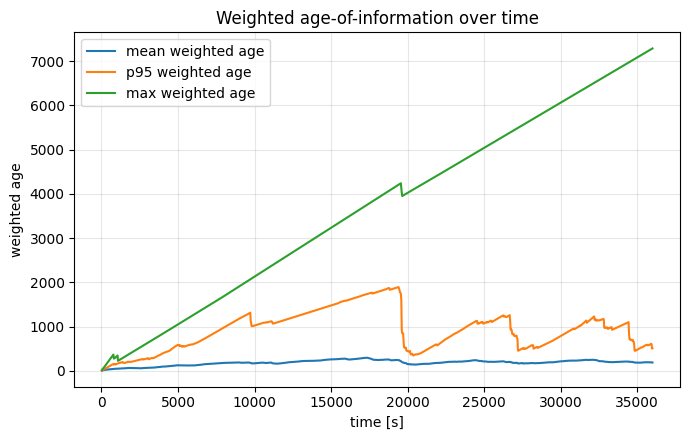

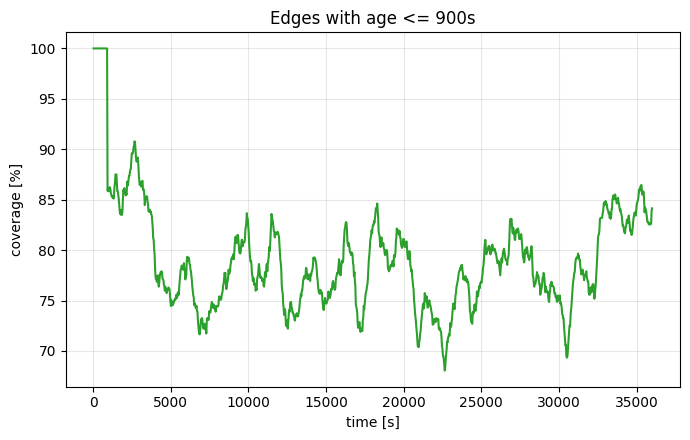

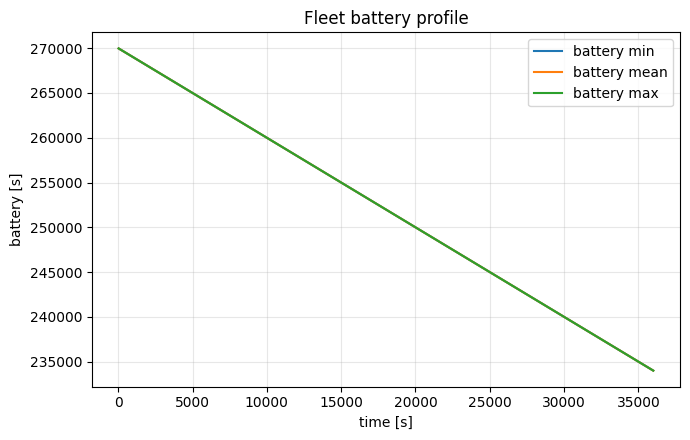

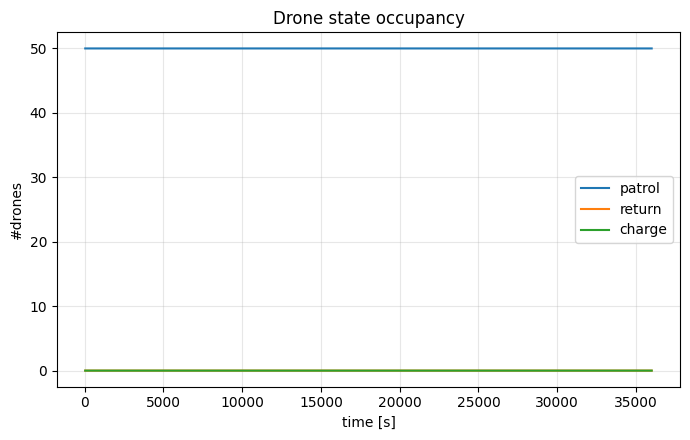

edge                                  visits   rate/h       W  last_age_s
------------------------------------------------------------------------------------
8498054802     -> 8498054804           698    69.80   0.563         2.0
8176369682     -> 7777187757           612    61.20   0.560       175.0
88485237       -> 8176401977           587    58.70   0.519       133.0
8176401977     -> 6541978855           587    58.70   0.519       138.0
4620787929     -> 8176401973           554    55.40   0.515        65.0
8176401973     -> 8176401976           554    55.40   0.515        69.0
8176401976     -> 88485237             554    55.40   0.454        86.0
88488753       -> 88532214             545    54.50   0.378        69.0
88532214       -> 88532216             545    54.50   0.377        80.0
7311009079     -> 88532216             545    54.50   0.376        84.0
8498067517     -> 696627308-Added      545    54.50   0.362       139.0
696627308-Added-> 6541978869           545    54.

In [6]:
if HAS_MPL:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(times, mean_weighted_age, label='mean weighted age')
    ax.plot(times, p95_weighted_age, label='p95 weighted age')
    ax.plot(times, max_weighted_age, label='max weighted age')
    ax.set_xlabel('time [s]')
    ax.set_ylabel('weighted age')
    ax.set_title('Weighted age-of-information over time')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(times, np.array(recent_coverage) * 100.0, color='tab:green')
    ax.set_xlabel('time [s]')
    ax.set_ylabel('coverage [%]')
    ax.set_title(f'Edges with age <= {AGE_SCALE_S:.0f}s')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(times, battery_min, label='battery min')
    ax.plot(times, battery_mean, label='battery mean')
    ax.plot(times, battery_max, label='battery max')
    ax.set_xlabel('time [s]')
    ax.set_ylabel('battery [s]')
    ax.set_title('Fleet battery profile')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(times, state_patrol, label='patrol')
    ax.plot(times, state_return, label='return')
    ax.plot(times, state_charge, label='charge')
    ax.set_xlabel('time [s]')
    ax.set_ylabel('#drones')
    ax.set_title('Drone state occupancy')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping plots because matplotlib is not available.')

top = sorted(edges, key=lambda e: visit_counts[e], reverse=True)[:20]
print(f"{'edge':<35} {'visits':>8} {'rate/h':>8} {'W':>7} {'last_age_s':>11}")
print('-' * 84)
for u, v in top:
    age = SIM_HORIZON_S - last_visit[(u, v)]
    rate = visit_counts[(u, v)] / (SIM_HORIZON_S / 3600.0)
    print(f"{u[:15]:<15}-> {v[:15]:<15} {visit_counts[(u,v)]:>8d} {rate:>8.2f} {W[(u,v)]:>7.3f} {age:>11.1f}")


## Scan-frequency analysis

This section summarizes **how often edges are scanned** and how scan effort is distributed.

- `visit_counts[e]`: number of completed traversals of edge `e`
- `visit_rate[e]`: scans per hour on edge `e`
- `avg_revisit[e]`: average revisit time (`SIM_HORIZON_S / visit_counts[e]`)
- `last_age[e]`: staleness at end of simulation (`SIM_HORIZON_S - last_visit[e]`)
- `visit_times[e]`: timestamps of scans (used for exact inter-visit interval stats)

In [7]:
scan_counts = np.array([visit_counts[e] for e in edges], dtype=float)
w_vals = np.array([W[e] for e in edges], dtype=float)
last_ages = np.array([SIM_HORIZON_S - last_visit[e] for e in edges], dtype=float)
visited_mask = scan_counts > 0

visit_rate = np.zeros_like(scan_counts)
visit_rate[visited_mask] = scan_counts[visited_mask] / (SIM_HORIZON_S / 3600.0)

avg_revisit = np.full_like(scan_counts, np.nan)
avg_revisit[visited_mask] = SIM_HORIZON_S / scan_counts[visited_mask]

exact_intervals = []
for e in edges:
    vt = visit_times[e]
    if len(vt) >= 2:
        exact_intervals.extend(np.diff(vt))
exact_intervals = np.array(exact_intervals, dtype=float) if exact_intervals else np.array([], dtype=float)

total_scans = int(scan_counts.sum())
visited_edges = int(visited_mask.sum())
never_visited = int((~visited_mask).sum())
sim_hours = SIM_HORIZON_S / 3600.0

print('Edge-scan summary')
print('------------------')
print(f'Total edge scans (all drones): {total_scans}')
print(f'Simulation horizon:            {SIM_HORIZON_S:.0f} s ({sim_hours:.2f} h)')
print(f'Aggregate scan rate:           {total_scans / sim_hours:.1f} scans/h')
print(f'Per-drone scan rate:           {total_scans / sim_hours / NUM_DRONES:.2f} scans/h/drone')
print(f'Edges scanned at least once:   {visited_edges} / {len(edges)} ({100*visited_edges/len(edges):.1f}%)')
print(f'Edges never scanned:           {never_visited}')

if visited_edges > 0:
    print(f'Median scans per visited edge: {np.median(scan_counts[visited_mask]):.1f}')
    print(f'P90 scans per visited edge:    {np.percentile(scan_counts[visited_mask], 90):.1f}')
    print(f'Median visit rate (visited):   {np.median(visit_rate[visited_mask]):.2f} scans/h')
    print(f'Median avg revisit (visited):  {np.median(avg_revisit[visited_mask]):.1f} s')
    print(f'P90 avg revisit (visited):     {np.percentile(avg_revisit[visited_mask], 90):.1f} s')

print(f'Median final edge age:         {np.median(last_ages):.1f} s')
print(f'P95 final edge age:            {np.percentile(last_ages, 95):.1f} s')
print(f'Edges fresher than {AGE_SCALE_S:.0f}s:   {100*np.mean(last_ages <= AGE_SCALE_S):.1f}%')

if exact_intervals.size > 0:
    print('Exact inter-visit intervals (from visit timestamps):')
    print(f'  Count intervals: {len(exact_intervals)}')
    print(f'  Median:          {np.median(exact_intervals):.1f} s')
    print(f'  P90:             {np.percentile(exact_intervals, 90):.1f} s')
    print(f'  P95:             {np.percentile(exact_intervals, 95):.1f} s')


Edge-scan summary
------------------
Total edge scans (all drones): 160325
Simulation horizon:            36000 s (10.00 h)
Aggregate scan rate:           16032.5 scans/h
Per-drone scan rate:           320.65 scans/h/drone
Edges scanned at least once:   1248 / 1249 (99.9%)
Edges never scanned:           1
Median scans per visited edge: 99.0
P90 scans per visited edge:    268.9
Median visit rate (visited):   9.90 scans/h
Median avg revisit (visited):  363.6 s
P90 avg revisit (visited):     1714.3 s
Median final edge age:         224.0 s
P95 final edge age:            3236.8 s
Edges fresher than 900s:   84.1%
Exact inter-visit intervals (from visit timestamps):
  Count intervals: 159077
  Median:          121.0 s
  P90:             621.0 s
  P95:             921.0 s


## 7) Weight-stratified scan behavior

Edges are grouped by weight quartiles to check whether high-priority edges
receive more scan effort and lower final age.

## 8) Scan distribution diagnostics

These plots explain allocation quality:
- scan-count histogram (fairness/concentration)
- final-age histogram (stale-tail behavior)
- weight vs scan-rate scatter (policy alignment)
- Pareto curve (how concentrated scans are)

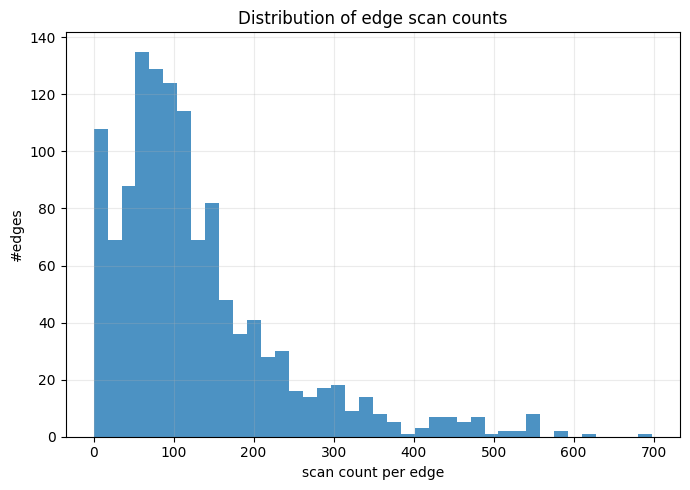

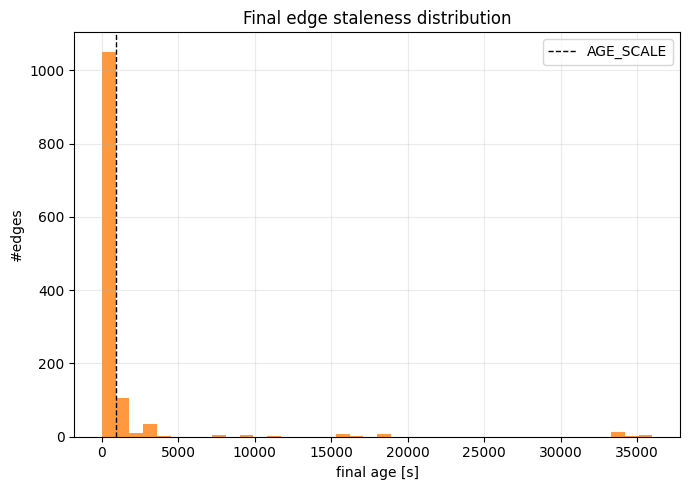

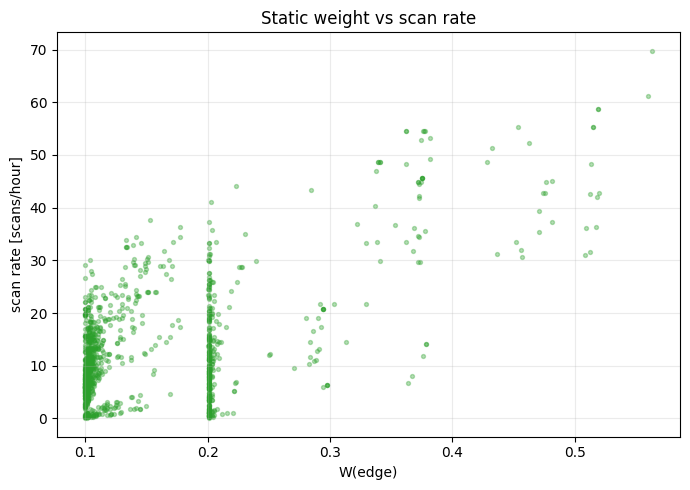

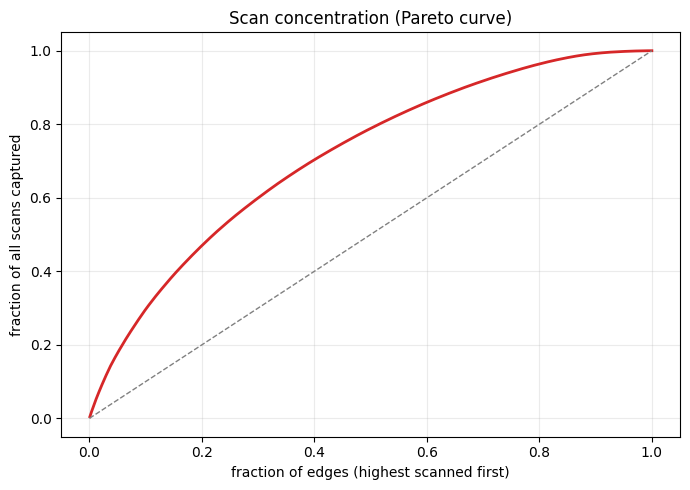

In [8]:
if HAS_MPL:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(scan_counts, bins=40, color='tab:blue', alpha=0.8)
    ax.set_title('Distribution of edge scan counts')
    ax.set_xlabel('scan count per edge')
    ax.set_ylabel('#edges')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(last_ages, bins=40, color='tab:orange', alpha=0.8)
    ax.axvline(AGE_SCALE_S, color='k', linestyle='--', linewidth=1, label='AGE_SCALE')
    ax.set_title('Final edge staleness distribution')
    ax.set_xlabel('final age [s]')
    ax.set_ylabel('#edges')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(w_vals, visit_rate, s=8, alpha=0.35, color='tab:green')
    ax.set_title('Static weight vs scan rate')
    ax.set_xlabel('W(edge)')
    ax.set_ylabel('scan rate [scans/hour]')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    order = np.argsort(scan_counts)[::-1]
    scans_sorted = scan_counts[order]
    cum_scans = np.cumsum(scans_sorted) / max(scans_sorted.sum(), 1.0)
    cum_edges = np.arange(1, len(scans_sorted)+1) / len(scans_sorted)
    ax.plot(cum_edges, cum_scans, color='tab:red', linewidth=2)
    ax.plot([0,1], [0,1], '--', color='gray', linewidth=1)
    ax.set_title('Scan concentration (Pareto curve)')
    ax.set_xlabel('fraction of edges (highest scanned first)')
    ax.set_ylabel('fraction of all scans captured')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping plots because matplotlib is not available.')


## 9) Spatial diagnostics

Map overlays for:
- edge scan rate
- final edge age

Use these to spot localized over-service or under-service regions and
charging-station-induced spatial bias.

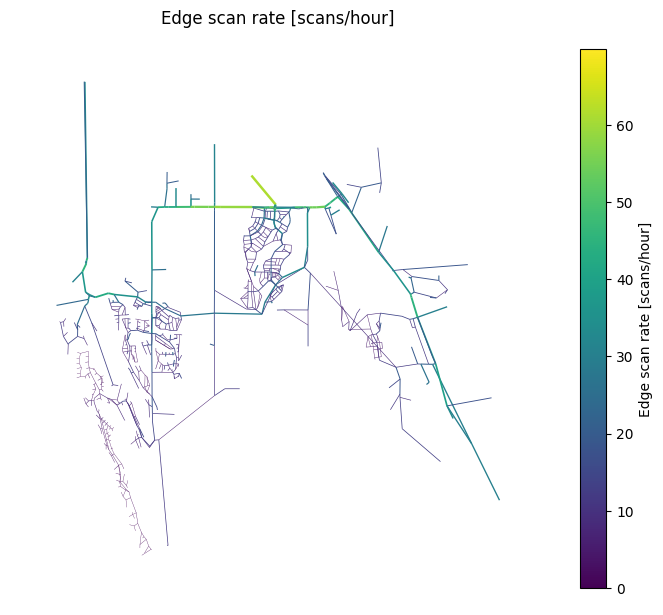

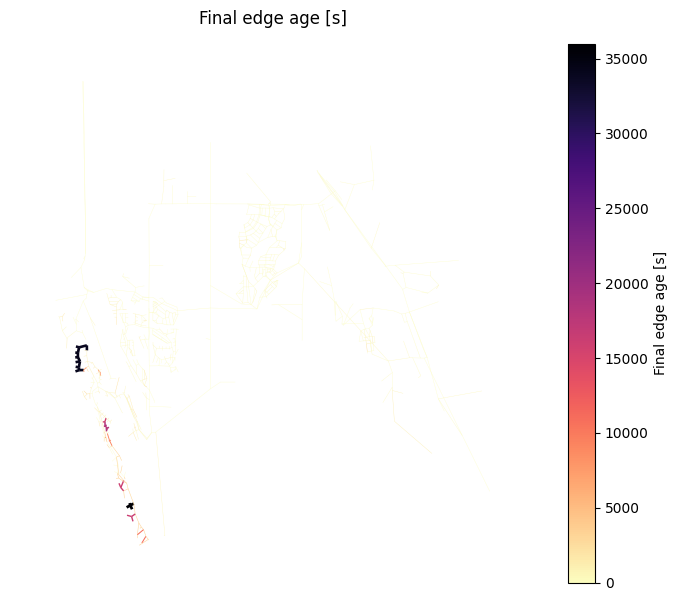

In [9]:
if HAS_MPL:
    pos = {n: (UG.nodes[n]['x'], UG.nodes[n]['y']) for n in UG.nodes()}
    edgelist = list(UG.edges())
    edge_to_idx = {e: i for i, e in enumerate(edges)}

    scans_draw = np.array([visit_rate[edge_to_idx[e]] for e in edgelist], dtype=float)
    age_draw = np.array([SIM_HORIZON_S - last_visit[e] for e in edgelist], dtype=float)

    def draw_metric(ax, vals, title, cmap):
        vmin = float(vals.min())
        vmax = float(vals.max())
        if vmax == vmin:
            vmax = vmin + 1e-9
        norm = (vals - vmin) / (vmax - vmin)
        colors = plt.get_cmap(cmap)(norm)
        widths = 0.2 + 1.8 * norm
        nx.draw_networkx_edges(UG, pos, edgelist=edgelist, edge_color=colors, width=widths, ax=ax)
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap), norm=plt.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, shrink=0.7, label=title)
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.axis('off')

    fig, ax = plt.subplots(figsize=(7, 8))
    draw_metric(ax, scans_draw, 'Edge scan rate [scans/hour]', 'viridis')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 8))
    draw_metric(ax, age_draw, 'Final edge age [s]', 'magma_r')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping map plots because matplotlib is not available.')


## 10) Expected vs observed attention alignment

This section renders where the swarm is *supposed* to focus (static edge weight `W`) versus where it *actually* focuses (observed scan rate).

- `W` map: static priority from SUMO-only weighting
- scan-rate map: realized patrol intensity
- delta map (`scan_norm - weight_norm`):
  - positive = over-served relative to assigned priority
  - negative = under-served relative to assigned priority

In [10]:
# Numeric alignment summary
edge_to_idx = {e: i for i, e in enumerate(edges)}
edgelist = list(UG.edges())
weight_draw = np.array([W[e] for e in edgelist], dtype=float)
scan_draw = np.array([visit_rate[edge_to_idx[e]] for e in edgelist], dtype=float)

# Robust normalization (cap at 95th percentile to reduce outlier dominance)
w_cap = max(np.percentile(weight_draw, 95), 1e-9)
s_cap = max(np.percentile(scan_draw, 95), 1e-9)
weight_norm = np.clip(weight_draw / w_cap, 0, 1)
scan_norm = np.clip(scan_draw / s_cap, 0, 1)
delta = scan_norm - weight_norm

pearson = float(np.corrcoef(weight_draw, scan_draw)[0, 1]) if len(weight_draw) > 1 else float('nan')
print('Expected vs observed attention')
print('-----------------------------')
print(f'Pearson corr(weight, scan_rate): {pearson:.3f}')
print('{:<8} {:>28} {:>44}'.format('Top-k', 'Overlap(weight vs scan)', 'Share of scans captured by top-weight set'))

for k in [5, 10, 20]:
    n = max(1, int(np.ceil(len(edgelist) * (k / 100.0))))
    idx_w = np.argsort(weight_draw)[-n:]
    idx_s = np.argsort(scan_draw)[-n:]
    overlap = 100.0 * len(set(idx_w).intersection(set(idx_s))) / n
    share_scans = 100.0 * scan_draw[idx_w].sum() / max(scan_draw.sum(), 1e-9)
    print('{:>3}% {:>24.1f}% {:>36.1f}%'.format(k, overlap, share_scans))

under_idx = np.argsort(delta)[:10]
over_idx = np.argsort(delta)[-10:][::-1]

print()
print('Most under-served edges (high expected, lower observed):')
print('{:<35} {:>7} {:>9} {:>8}'.format('edge', 'W', 'rate/h', 'delta'))
for i in under_idx:
    u, v = edgelist[i]
    print('{:<15}-> {:<15} {:>7.3f} {:>9.2f} {:>8.3f}'.format(str(u)[:15], str(v)[:15], weight_draw[i], scan_draw[i], delta[i]))

print()
print('Most over-served edges (observed > expected):')
print('{:<35} {:>7} {:>9} {:>8}'.format('edge', 'W', 'rate/h', 'delta'))
for i in over_idx:
    u, v = edgelist[i]
    print('{:<15}-> {:<15} {:>7.3f} {:>9.2f} {:>8.3f}'.format(str(u)[:15], str(v)[:15], weight_draw[i], scan_draw[i], delta[i]))


Expected vs observed attention
-----------------------------
Pearson corr(weight, scan_rate): 0.604
Top-k         Overlap(weight vs scan)    Share of scans captured by top-weight set
  5%                     74.6%                                 16.2%
 10%                     59.2%                                 23.9%
 20%                     46.4%                                 34.4%

Most under-served edges (high expected, lower observed):
edge                                      W    rate/h    delta
88475252       -> 88479583          0.364      6.70   -0.806
88479583       -> 88510748          0.367      8.10   -0.765
88511213       -> 88510829          0.294      6.00   -0.690
88511213       -> 88511215          0.298      6.40   -0.687
88511225       -> 88511215          0.298      6.40   -0.687
88500866       -> 88511225          0.298      6.40   -0.687
88478348       -> 1471798187        0.376     11.90   -0.655
88486047       -> 88511024          0.221      1.10   -0.616
8

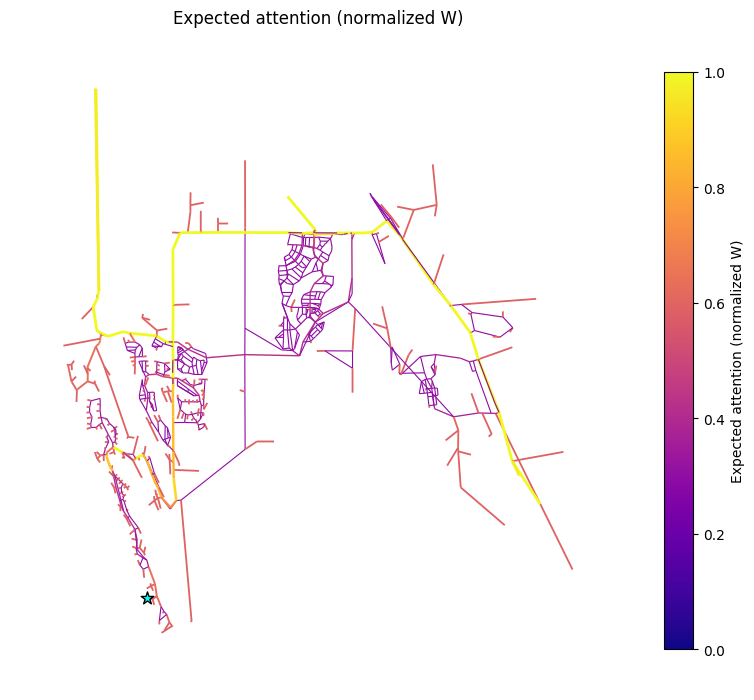

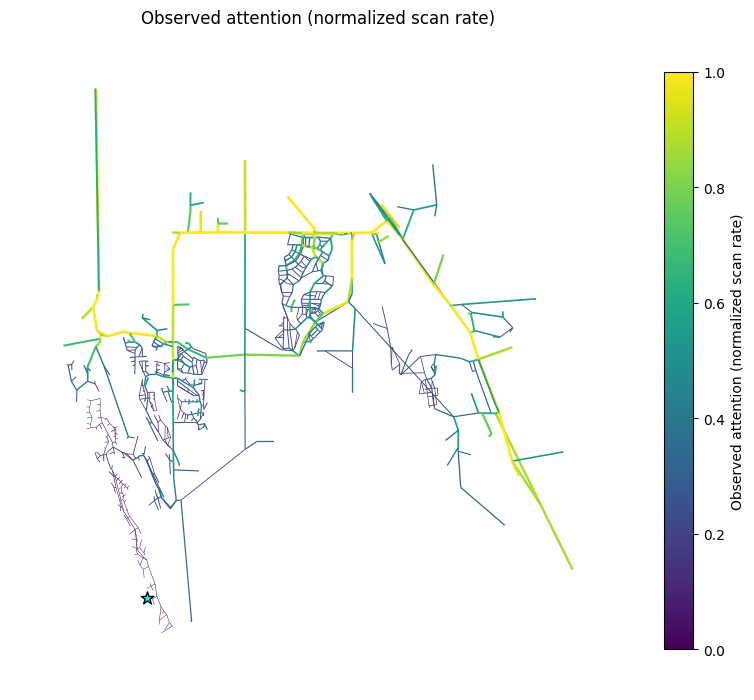

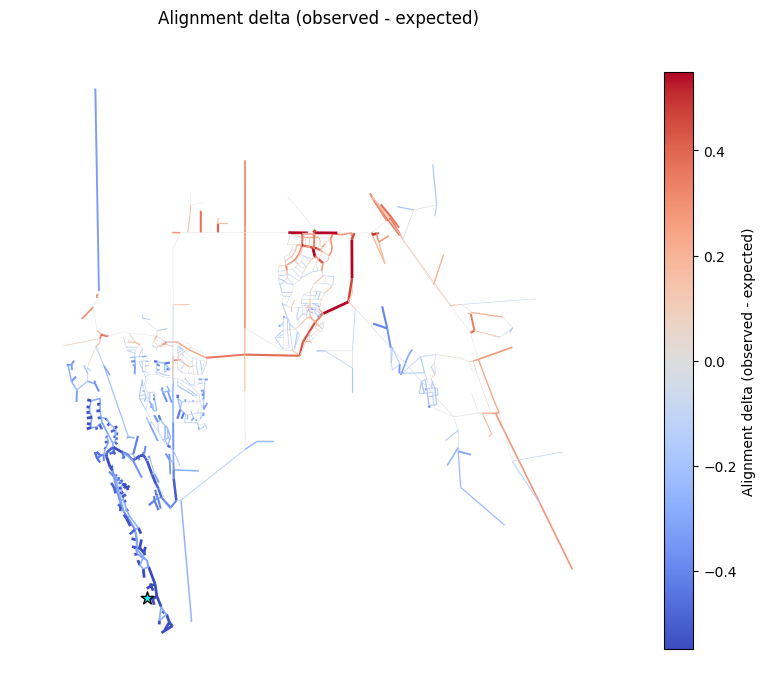

In [11]:
if HAS_MPL:
    import matplotlib.colors as mcolors

    pos = {n: (UG.nodes[n]['x'], UG.nodes[n]['y']) for n in UG.nodes()}
    edgelist = list(UG.edges())

    weight_draw = np.array([W[e] for e in edgelist], dtype=float)
    edge_to_idx = {e: i for i, e in enumerate(edges)}
    scan_draw = np.array([visit_rate[edge_to_idx[e]] for e in edgelist], dtype=float)

    w_cap = max(np.percentile(weight_draw, 95), 1e-9)
    s_cap = max(np.percentile(scan_draw, 95), 1e-9)
    weight_norm = np.clip(weight_draw / w_cap, 0, 1)
    scan_norm = np.clip(scan_draw / s_cap, 0, 1)
    delta = scan_norm - weight_norm

    def draw_metric(ax, vals, title, cmap, vmin, vmax, center=None):
        if center is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
        colors = plt.get_cmap(cmap)(norm(vals))
        if center is None:
            widths = 0.3 + 1.7 * np.clip((vals - vmin) / max(vmax - vmin, 1e-9), 0, 1)
        else:
            widths = 0.3 + 1.7 * np.clip(np.abs(vals) / max(abs(vmin), abs(vmax), 1e-9), 0, 1)
        nx.draw_networkx_edges(UG, pos, edgelist=edgelist, edge_color=colors, width=widths, ax=ax)
        ax.scatter([station_xy[0]], [station_xy[1]], c='cyan', edgecolors='black', s=90, marker='*', zorder=5)
        sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap), norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, shrink=0.75, label=title)
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.axis('off')

    fig, ax = plt.subplots(figsize=(8, 8))
    draw_metric(ax, weight_norm, 'Expected attention (normalized W)', 'plasma', 0.0, 1.0)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 8))
    draw_metric(ax, scan_norm, 'Observed attention (normalized scan rate)', 'viridis', 0.0, 1.0)
    plt.tight_layout()
    plt.show()

    d_lim = max(np.percentile(np.abs(delta), 95), 1e-6)
    fig, ax = plt.subplots(figsize=(8, 8))
    draw_metric(ax, delta, 'Alignment delta (observed - expected)', 'coolwarm', -d_lim, d_lim, center=0.0)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping alignment maps because matplotlib is not available.')


## 11) GIF: graph evolution over time

This block reruns the patrol simulation and exports a GIF with three synchronized views:
- expected attention (static `W`)
- observed scan rate up to current time
- freshness (`1 - normalized age`)

Use this to see how the swarm's exploration evolves and where lock-in appears.

In [ ]:
# GIF generation for intuitive evolution view (inline display)
# Requires: matplotlib + imageio
try:
    import imageio.v2 as imageio
except Exception as exc:
    raise RuntimeError("Please install imageio first: pip install imageio") from exc

from io import BytesIO

if not HAS_MPL:
    raise RuntimeError("matplotlib is required for GIF generation.")

try:
    from IPython.display import display, Image
    HAS_IPY = True
except Exception:
    HAS_IPY = False

import matplotlib.colors as mcolors

# --- GIF controls ---
GIF_SIM_HORIZON_S = 7200          # set to SIM_HORIZON_S for full run
GIF_FRAME_EVERY_S = 120           # capture every N simulation seconds
GIF_FPS = 6
GIF_MAX_FRAMES = 120              # hard cap for runtime safety

# Optional file save (disabled by default)
SAVE_GIF_TO_FILE = False
GIF_PATH = 'aco_evolution.gif'

# Re-run simulation from scratch using current notebook parameters
edges_local = list(UG.edges())

tau_l = {e: PHEROMONE_INIT for e in edges_local}
last_l = {e: 0.0 for e in edges_local}
inflight_l = {e: 0 for e in edges_local}
visit_counts_l = {e: 0 for e in edges_local}

rng_l = random.Random(RNG_SEED)

# spawn policy from notebook config
if 'SPAWN_MODE' in globals() and SPAWN_MODE == 'random':
    start_nodes_l = [rng_l.choice(nodes) for _ in range(NUM_DRONES)]
else:
    start_nodes_l = [station_node for _ in range(NUM_DRONES)]

drones_l = []
for i in range(NUM_DRONES):
    drones_l.append({
        'node': start_nodes_l[i],
        'edge': None,
        'target': None,
        'remaining': 0.0,
        'state': 'patrol',
        'battery_s': BATTERY_ENDURANCE_S,
        'charge_remaining_s': 0.0,
    })


def edge_key_l(u, v):
    if (u, v) in tau_l:
        return (u, v)
    return (v, u)


def edge_travel_time_l(u, v):
    e = edge_key_l(u, v)
    return max(edge_length[e] / CRUISE_SPEED_MPS, 1.0)


def heuristic_l(e, t):
    age = t - last_l[e]
    age_term = min(age / AGE_SCALE_S, 3.0)
    return 1e-6 + 0.4 * W[e] + 0.6 * age_term


def should_return_l(drone):
    tts = time_to_station.get(drone['node'], np.inf)
    if not np.isfinite(tts):
        return False
    return drone['battery_s'] <= (tts + RESERVE_SECONDS)


def can_safely_traverse_l(u, v, battery_s):
    t_edge = edge_travel_time_l(u, v)
    tts_next = time_to_station.get(v, np.inf)
    if not np.isfinite(tts_next):
        return False
    return (battery_s - t_edge - tts_next) >= RESERVE_SECONDS


def choose_next_edge_l(node, t, battery_s):
    nbrs = list(UG.neighbors(node))
    if not nbrs:
        return None, None

    scores = []
    for v in nbrs:
        if not can_safely_traverse_l(node, v, battery_s):
            continue
        e = edge_key_l(node, v)
        h = heuristic_l(e, t)
        s = (tau_l[e] ** ALPHA) * (h ** BETA) / ((1.0 + inflight_l[e]) ** GAMMA_OVERLAP)
        scores.append((v, e, max(s, 1e-12)))

    if not scores:
        return None, None

    total = sum(s for _, _, s in scores)
    r = rng_l.random() * total
    c = 0.0
    for v, e, s in scores:
        c += s
        if c >= r:
            return v, e
    return scores[-1][0], scores[-1][1]


def start_edge_l(drone, target_node, edge, mode):
    inflight_l[edge] += 1
    drone['edge'] = edge
    drone['target'] = target_node
    drone['remaining'] = edge_travel_time_l(drone['node'], target_node)
    drone['state'] = mode


def enter_charge_l(drone):
    drone['state'] = 'charge'
    drone['edge'] = None
    drone['target'] = None
    drone['remaining'] = 0.0
    drone['charge_remaining_s'] = RECHARGE_DURATION_S


def dispatch_return_l(drone, t):
    if drone['node'] == station_node:
        enter_charge_l(drone)
        return
    path = nx.shortest_path(UG, source=drone['node'], target=station_node, weight='length')
    if len(path) < 2:
        enter_charge_l(drone)
        return
    nxt = path[1]
    e = edge_key_l(drone['node'], nxt)
    start_edge_l(drone, nxt, e, mode='return')


def dispatch_patrol_l(drone, t):
    if should_return_l(drone):
        dispatch_return_l(drone, t)
        return

    nxt, e = choose_next_edge_l(drone['node'], t, drone['battery_s'])
    if e is None:
        dispatch_return_l(drone, t)
        return

    tau_l[e] = (1.0 - LOCAL_DECAY) * tau_l[e] + LOCAL_DECAY * PHEROMONE_INIT
    start_edge_l(drone, nxt, e, mode='patrol')


for d in drones_l:
    dispatch_patrol_l(d, 0.0)

# plotting setup
pos_l = {n: (UG.nodes[n]['x'], UG.nodes[n]['y']) for n in UG.nodes()}
edgelist_l = list(UG.edges())

w_vals = np.array([W[e] for e in edgelist_l], dtype=float)
w_cap = max(np.percentile(w_vals, 95), 1e-9)
w_norm = np.clip(w_vals / w_cap, 0, 1)

frames = []
captured = 0

for step in range(1, int(GIF_SIM_HORIZON_S / DT_S) + 1):
    t = step * DT_S

    for e in edges_local:
        tau_l[e] *= (1.0 - GLOBAL_EVAP_RATE)

    for d in drones_l:
        if d['state'] == 'charge':
            charge_rate = BATTERY_ENDURANCE_S / RECHARGE_DURATION_S
            d['battery_s'] = min(BATTERY_ENDURANCE_S, d['battery_s'] + charge_rate * DT_S)
            d['charge_remaining_s'] -= DT_S
            if d['charge_remaining_s'] <= 1e-12:
                d['battery_s'] = BATTERY_ENDURANCE_S
                d['charge_remaining_s'] = 0.0
                d['state'] = 'patrol'
                dispatch_patrol_l(d, t)
            continue

        if d['edge'] is None:
            if d['state'] == 'return':
                dispatch_return_l(d, t)
            else:
                dispatch_patrol_l(d, t)
            continue

        d['remaining'] -= DT_S
        d['battery_s'] = max(0.0, d['battery_s'] - DT_S)

        while d['edge'] is not None and d['remaining'] <= 1e-12:
            e = d['edge']
            inflight_l[e] = max(inflight_l[e] - 1, 0)

            d['node'] = d['target']
            d['edge'] = None
            d['target'] = None
            d['remaining'] = 0.0

            if d['state'] == 'patrol':
                age_before = t - last_l[e]
                last_l[e] = t
                visit_counts_l[e] += 1
                age_term = min(age_before / AGE_SCALE_S, 1.0)
                tau_l[e] += DEPOSIT_GAIN * (0.5 * W[e] + 0.5 * age_term)
                dispatch_patrol_l(d, t)
            else:
                if d['node'] == station_node:
                    enter_charge_l(d)
                else:
                    dispatch_return_l(d, t)

    if step % int(GIF_FRAME_EVERY_S / DT_S) == 0:
        rates = np.array([visit_counts_l[e] for e in edgelist_l], dtype=float) / max((t / 3600.0), 1e-9)
        r_cap = max(np.percentile(rates, 95), 1e-9)
        r_norm = np.clip(rates / r_cap, 0, 1)

        ages = np.array([t - last_l[e] for e in edgelist_l], dtype=float)
        a_cap = max(np.percentile(ages, 95), 1e-9)
        fresh = 1.0 - np.clip(ages / a_cap, 0, 1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        def draw(ax, vals, title, cmap):
            norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
            colors = plt.get_cmap(cmap)(norm(vals))
            widths = 0.2 + 1.8 * vals
            nx.draw_networkx_edges(UG, pos_l, edgelist=edgelist_l, edge_color=colors, width=widths, ax=ax)
            ax.scatter([station_xy[0]], [station_xy[1]], c='cyan', edgecolors='black', s=80, marker='*', zorder=5)
            sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap), norm=norm)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, shrink=0.72)
            ax.set_title(title)
            ax.set_aspect('equal')
            ax.axis('off')

        draw(axes[0], w_norm, 'Expected attention (W norm)', 'plasma')
        draw(axes[1], r_norm, f'Observed scan rate (t={int(t)}s)', 'viridis')
        draw(axes[2], fresh, 'Freshness (higher=more recent)', 'magma')

        fig.suptitle(f'ACO evolution | t={int(t)}s | visited edges={int(np.sum(np.array(list(visit_counts_l.values()))>0))}/{len(edgelist_l)}', fontsize=12)
        fig.tight_layout()
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)
        plt.close(fig)

        captured += 1
        if captured >= GIF_MAX_FRAMES:
            break

if not frames:
    raise RuntimeError('No frames generated. Check GIF_FRAME_EVERY_S and GIF_SIM_HORIZON_S settings.')

# Build GIF bytes in memory and display inline
buf = BytesIO()
imageio.mimsave(buf, frames, format='GIF', fps=GIF_FPS)
buf.seek(0)

if SAVE_GIF_TO_FILE:
    with open(GIF_PATH, 'wb') as f:
        f.write(buf.getvalue())
    print(f'GIF also saved to: {GIF_PATH}')

if HAS_IPY:
    display(Image(data=buf.getvalue(), format='gif'))
else:
    print('IPython display not available; enable SAVE_GIF_TO_FILE=True to write the GIF.')

print(f'GIF frames: {len(frames)}, FPS: {GIF_FPS}, simulated horizon: {GIF_SIM_HORIZON_S}s')
